In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import seaborn as sns
import glob

In [2]:
files = glob.glob("traces_127417834/*pol*")

In [3]:
len(files)//2

262

In [5]:
trim = 8000
dur = 100
sig_window = 20

In [4]:
def modify_data(data, trim):
    modified = pd.concat([data.columns.to_frame().T, data]).reset_index(drop=True).iloc[:,0].str.split(expand=True).astype(float)
    return modified.iloc[:,1].values[trim:-trim]

In [6]:
for i in range(len(files)):
    data = pd.read_csv(files[i], delimiter="\t")
    modified = modify_data(data, trim)

    if i == 0:
        traces = np.empty((len(files), *modified.shape))
    
    traces[i] = modified

In [7]:
traces.shape

(524, 49536)

In [8]:
def remove_signal(trace, sig_window):
    sig = np.argmax(trace)
    return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1))

def get_reals(trace, dur):
    to_consider = trace[:-(len(trace)%dur)]
    return np.split(to_consider, len(to_consider)/dur)

def make_cov(trace, duration, sig_window):
    new_trace = remove_signal(trace, sig_window)
    reals = np.array(get_reals(new_trace, duration))
    N = len(reals)

    if N==0:
        return np.zeros((duration, duration)), N

    return np.cov(reals.T), N

In [9]:
def extract_nums(file):
    words = file.split('/')[-1].split('_')

    stn = int(words[1].replace('station', '')) 
    chn = int(words[2].replace('channel', ''))  

    return stn, chn

In [10]:
import os
def get_covs(traces, dur, sig_window, files):

    num = traces.shape[0]
    covs = np.empty((num, dur, dur))

    dirname = os.path.join("results/Covs", f"{dur}")
    if os.path.exists(dirname) == False:
        os.mkdir(dirname)

    for j in range(num):
        cov, N = make_cov(traces[j], dur, sig_window)
        covs[j] = cov

        stn, chn = extract_nums(files[j])

        dircovname = os.path.join(dirname, f"{stn}-{chn}")
        if os.path.exists(dircovname) == False:
            os.mkdir(dircovname)


        cov_name = f"{stn}-{chn}.npy"
        fn_cov = os.path.join(dircovname, cov_name)
        np.save(fn_cov, cov)

    return covs, N

In [11]:
covs, N = get_covs(traces, dur, sig_window, files)

In [12]:
covs

array([[[ 2.21956823e-08, -5.06779896e-09, -1.81541503e-08, ...,
          9.97226738e-10, -2.82885065e-10, -9.12323224e-10],
        [-5.06779896e-09,  2.11276567e-08, -5.71098820e-09, ...,
          6.23371275e-10, -7.03214576e-10, -3.24550874e-10],
        [-1.81541503e-08, -5.71098820e-09,  2.24929744e-08, ...,
         -1.55419019e-09,  5.62063323e-10,  1.23414178e-09],
        ...,
        [ 9.97226738e-10,  6.23371275e-10, -1.55419019e-09, ...,
          2.22645004e-08, -4.74018158e-09, -1.81879712e-08],
        [-2.82885065e-10, -7.03214576e-10,  5.62063323e-10, ...,
         -4.74018158e-09,  2.14929141e-08, -5.41769003e-09],
        [-9.12323224e-10, -3.24550874e-10,  1.23414178e-09, ...,
         -1.81879712e-08, -5.41769003e-09,  2.20320010e-08]],

       [[ 2.21437031e-08, -4.85113218e-09, -1.77282228e-08, ...,
          2.35424563e-09, -7.21635954e-10, -2.56852240e-09],
        [-4.85113218e-09,  2.20180504e-08, -6.69849376e-09, ...,
         -1.49988091e-10,  2.88011584e

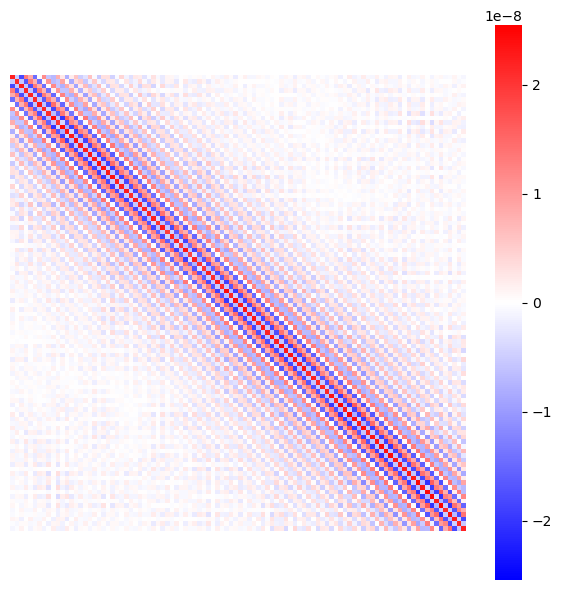

In [13]:
plt.figure(figsize=(6,6))
sns.heatmap(covs[0], xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
# plt.title(f"{stns[j]}-{chns[j]}[Size: {dur} ({dur*5} ns)]")
plt.tight_layout()
plt.show()

In [14]:
def draw_cov(covs, dur, files):

    for i in range(covs.shape[0]):
        stn, chn = extract_nums(files[i])
        plt.figure(figsize=(6,6))
        sns.heatmap(covs[i], xticklabels=False, yticklabels=False, square=True, cmap="bwr", norm=colors.CenteredNorm())
        plt.title(f"{stn}-{chn} [Size: {dur} ({dur*5} ns)]")
        plt.tight_layout()

        dirname = f"results/Covs/{dur}/{stn}-{chn}"
        fn = os.path.join(dirname, "covs.png")
        plt.savefig(fn, dpi=300, bbox_inches='tight')
        plt.close()

In [15]:
draw_cov(covs, 100, files)

In [16]:
np.save("results/Covs/100/all_covs.npy", covs)